# Importing Libraries

- NumPy is used for numerical computations and matrix operations.
- Pandas is used for loading and handling the dataset.
- Matplotlib is used for visualization and plotting graphs.

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data.csv")

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


# Data Preprocessing

In this step:

- The diagnosis labels are saved separately for later evaluation and visualization.
- Unnecessary columns such as `id` and `Unnamed: 32` are removed.
- The diagnosis column is removed because clustering is an unsupervised learning task.
- The dataset is converted into a NumPy array for numerical processing.

In [19]:
# Save labels for later evaluation only
labels = df["diagnosis"]

# Remove unnecessary columns
df = df.drop(columns=["id", "Unnamed: 32", "diagnosis"])

# Convert to NumPy array
X = df.values

print(X.shape)

(569, 30)


# Data Standardization

The dataset features are standardized before applying K-Means clustering.

Standardization is important because K-Means depends on distance calculations. Features with larger values may dominate the clustering process.


In [20]:
mean = np.mean(X, axis=0)

std = np.std(X, axis=0)

X_scaled = (X - mean) / std

print(X_scaled.shape)

(569, 30)


# K-Means Implementation

The K-Means clustering algorithm is implemented from scratch using NumPy.

Main steps of the algorithm:

1. Randomly initialize centroids.
2. Compute distances between points and centroids.
3. Assign each point to the nearest centroid.
4. Update centroid positions using cluster means.
5. Repeat the process until convergence.

The implementation also includes:
- SSE computation
- Empty cluster handling
- Convergence checking

In [12]:
class KMeans:
    
    def __init__(self, k=2, max_iters=100):

        self.k = k
        self.max_iters = max_iters


    # Initialize centroids randomly
    def initialize_centroids(self, X):

        indices = np.random.choice(
            X.shape[0],
            self.k,
            replace=False
        )

        centroids = X[indices]

        return centroids


    # Assign each point to nearest centroid
    def assign_clusters(self, X, centroids):

        distances = np.linalg.norm(
            X[:, np.newaxis] - centroids,
            axis=2
        )

        labels = np.argmin(distances, axis=1)

        return labels


    # Update centroid positions
    def update_centroids(self, X, labels):

        centroids = []

        for i in range(self.k):

            cluster_points = X[labels == i]

            # Handle empty clusters
            if len(cluster_points) == 0:

                centroid = X[
                    np.random.choice(X.shape[0])
                ]

            else:

                centroid = cluster_points.mean(axis=0)

            centroids.append(centroid)

        return np.array(centroids)


    # Compute SSE
    def compute_sse(self, X, labels, centroids):

        sse = 0

        for i in range(self.k):

            cluster_points = X[labels == i]

            sse += np.sum(
                (cluster_points - centroids[i]) ** 2
            )

        return sse


    # Train model
    def fit(self, X):

        centroids = self.initialize_centroids(X)

        for _ in range(self.max_iters):

            labels = self.assign_clusters(X, centroids)

            new_centroids = self.update_centroids(
                X,
                labels
            )

            # Stop if converged
            if np.allclose(centroids, new_centroids):

                break

            centroids = new_centroids

        sse = self.compute_sse(
            X,
            labels,
            centroids
        )

        self.centroids = centroids
        self.labels = labels
        self.sse = sse

# Running K-Means

The K-Means algorithm is executed using \(k = 2\) clusters.

After training:
- Cluster assignments are generated.
- Centroids are updated iteratively.
- The SSE value is computed to evaluate cluster compactness.

In [13]:
model = KMeans(k=2)

model.fit(X_scaled)

print("SSE =", model.sse)

SSE = 11595.683312822135


# Elbow Method

The elbow method is used to determine the optimal number of clusters.

The K-Means algorithm is executed using different values of \(k\), and the SSE is calculated for each case.

The optimal \(k\) is typically located near the "elbow" point where the SSE reduction becomes less significant.

In [14]:
sse_values = []

k_values = range(1, 11)

for k in k_values:

    model = KMeans(k=k)

    model.fit(X_scaled)

    sse_values.append(model.sse)

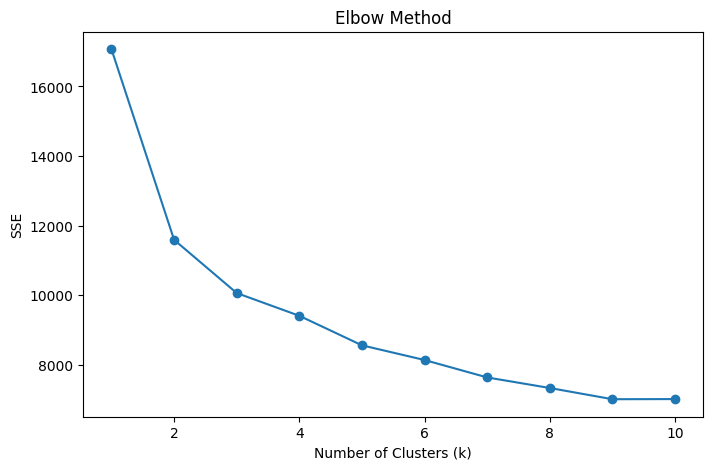

In [15]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    sse_values,
    marker='o'
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("SSE")
plt.title("Elbow Method")

plt.show()

# Multiple Initializations

K-Means is sensitive to random centroid initialization.

To improve clustering quality, the algorithm is executed multiple times with different random initializations, and the model with the lowest SSE is selected.

In [16]:
best_model = None

best_sse = float('inf')

for _ in range(10):

    model = KMeans(k=2)

    model.fit(X_scaled)

    if model.sse < best_sse:

        best_sse = model.sse

        best_model = model

print("Best SSE =", best_sse)

Best SSE = 11595.526607115786


# Cluster Visualization

The clustering results are visualized using a scatter plot.

- Different colors represent different clusters.
- The large "X" markers represent cluster centroids.

This visualization helps understand how the data points are grouped.

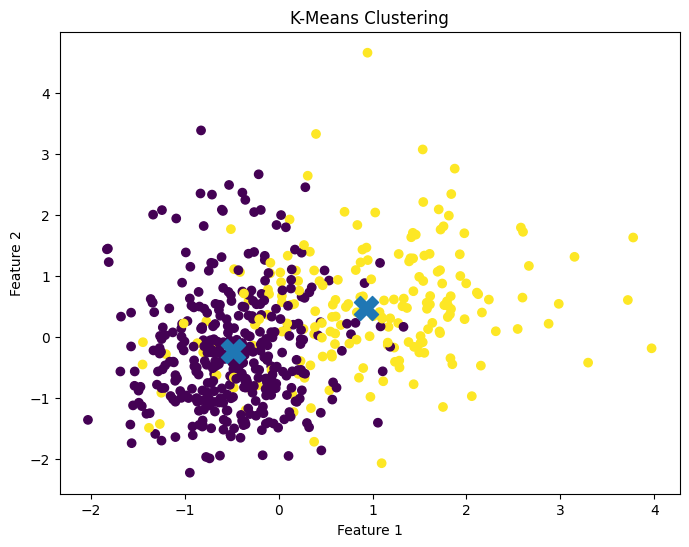

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=best_model.labels
)

plt.scatter(
    best_model.centroids[:, 0],
    best_model.centroids[:, 1],
    s=300,
    marker='X'
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.title("K-Means Clustering")

plt.show()


Trying with 1 components:
Percentage held by each individual component:
[4.42720256e-01 1.89711820e-01 9.39316326e-02 6.60213492e-02
 5.49576849e-02 4.02452204e-02 2.25073371e-02 1.58872380e-02
 1.38964937e-02 1.16897819e-02 9.79718988e-03 8.70537901e-03
 8.04524987e-03 5.23365745e-03 3.13783217e-03 2.66209337e-03
 1.97996793e-03 1.75395945e-03 1.64925306e-03 1.03864675e-03
 9.99096464e-04 9.14646751e-04 8.11361259e-04 6.01833567e-04
 5.16042379e-04 2.72587995e-04 2.30015463e-04 5.29779290e-05
 2.49601032e-05 4.43482743e-06]

Running total as we add components together:
[0.44272026 0.63243208 0.72636371 0.79238506 0.84734274 0.88758796
 0.9100953  0.92598254 0.93987903 0.95156881 0.961366   0.97007138
 0.97811663 0.98335029 0.98648812 0.98915022 0.99113018 0.99288414
 0.9945334  0.99557204 0.99657114 0.99748579 0.99829715 0.99889898
 0.99941502 0.99968761 0.99991763 0.99997061 0.99999557 1.        ]

Trying with 2 components:
Percentage held by each individual component:
[4.42720256e-

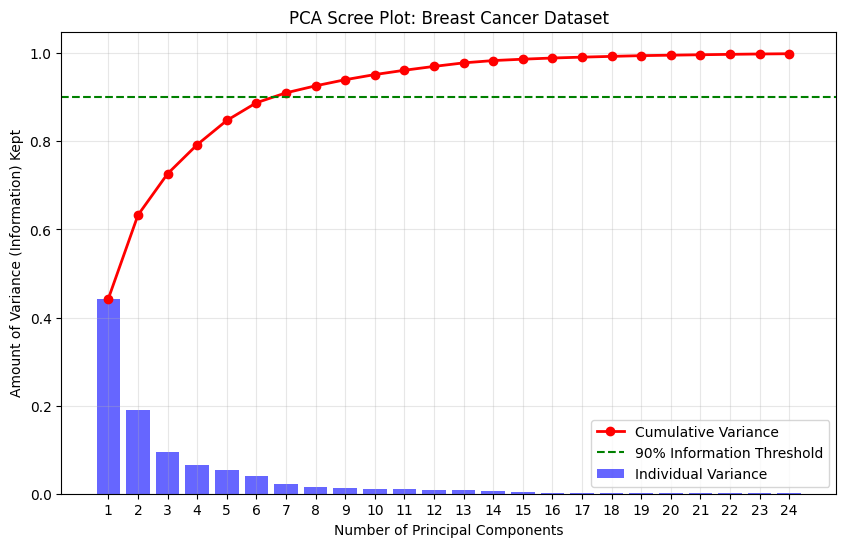

In [ ]:
#steps for pca 
#get mean of each feature and calc covariance matrix for each component 
#calc eigenvalues and eigenvectors for each component and sort them in descending order of eigenvalues
#pick k eigenvalues and form matrix of eigenvectors 
#transform the original data to new space using the matrix of eigenvectors
def PCA (X_Scaled, n_components=2):
    covariance_matrix = np.cov(X_Scaled, rowvar=False) #covariance matrix calc

    # Step 2: Eigen decomposition
    eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)

    # Step 3: Sort eigenvalues and eigenvectors
    sorted_indices = np.argsort(eigenvalues)[::-1]
    #apply sorting to eigenvalues and eigenvectors
    sorted_eigenvalues = eigenvalues[sorted_indices]
    sorted_eigenvectors = eigenvectors[:, sorted_indices]

    # Step 4: Select top n_components
    selected_eigenvectors = sorted_eigenvectors[:, :n_components]

    # Transform data
    X_reduced = np.dot(X_Scaled, selected_eigenvectors)
    #variance calc
    sum = np.sum(sorted_eigenvalues)
    variance_explained = sorted_eigenvalues / sum
    running_total_variance = np.cumsum(variance_explained)

    print("Percentage held by each individual component:")
    print(variance_explained)

    print("\nRunning total as we add components together:")
    print(running_total_variance)

    return X_reduced, variance_explained, running_total_variance

def try_different_components():
    arr=[]
    for i in range(1 , 25):
        print(f"\nTrying with {i} components:")
        X_reduced , variance_per_feature, total_variance = PCA(X_scaled, n_components=i)
        arr.append((i , variance_per_feature , total_variance))
    return arr

array = try_different_components()

# 1. Create empty lists to hold the unpacked data for the graph
x_values = []
individual_variance = []
cumulative_variance = []

# 2. Loop through your array and extract the correct numbers
for item in array:
    i = item[0]                 # The number of components (1 through 24)
    all_ind_vars = item[1]      # The array of individual percentages
    all_cum_vars = item[2]      # The array of running totals
    
    x_values.append(i)
    
    # Grab the specific variance for the i-th component (arrays start at index 0, so we use i-1)
    individual_variance.append(all_ind_vars[i-1])
    cumulative_variance.append(all_cum_vars[i-1])

# 3. Plot the unpacked data
plt.figure(figsize=(10, 6))

# Use x_values instead of range(), and our new unpacked lists
plt.bar(x_values, individual_variance, alpha=0.6, color='blue', 
        label='Individual Variance')

plt.plot(x_values, cumulative_variance, marker='o', color='red', linewidth=2, 
         label='Cumulative Variance')

plt.axhline(y=0.90, color='green', linestyle='--', label='90% Information Threshold')

# Formatting
plt.title('PCA Scree Plot: Breast Cancer Dataset')
plt.xlabel('Number of Principal Components')
plt.ylabel('Amount of Variance (Information) Kept')
plt.xticks(x_values) # Set the tick marks to match your 1-24 range perfectly
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

plt.show()

## K Means Clustering Implementation

In [27]:
def intialize_centroids(X, k):
    indices = np.random.choice(X.shape[0], k, replace=False)
    print ("Randomly selected indices for centroids:", indices)
    centroids = X[indices]
    return centroids

def assign_clusters(X, centroids):
    distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
    labels = np.argmin(distances, axis=1)
    return labels

def update_centroids(X, labels, k):
    centroids = []
    for i in range(k):
        cluster_points = X[labels == i]
        if len(cluster_points) == 0:
            centroid = X[np.random.choice(X.shape[0])]
        else:
            centroid = cluster_points.mean(axis=0)
        centroids.append(centroid)
    return np.array(centroids)

def compute_sse(X, labels, centroids, k):
    sse = 0
    for i in range(k):
        cluster_points = X[labels == i]
        sse += np.sum((cluster_points - centroids[i]) ** 2)
    return sse


### use for the small functions above 

In [29]:
def kmeans(X, k, max_iters=100):
    # intialize centroids
    centroids = intialize_centroids(X, k)

    for _ in range(max_iters):
        # assign each point to nearest centroid 
        labels = assign_clusters(X, centroids)

        # recompute centroids
        new_centroids = update_centroids(X, labels, k)

        # convergence check
        if np.allclose(centroids, new_centroids):
            break

        centroids = new_centroids
    sse = compute_sse(X, labels, centroids, k)

    return labels, centroids, sse

labels, centroids, sse = kmeans(X_scaled, k=2)
print("SSE:", sse)

Randomly selected indices for centroids: [285  53]
SSE: 11595.526607115786


Percentage held by each individual component:
[4.42720256e-01 1.89711820e-01 9.39316326e-02 6.60213492e-02
 5.49576849e-02 4.02452204e-02 2.25073371e-02 1.58872380e-02
 1.38964937e-02 1.16897819e-02 9.79718988e-03 8.70537901e-03
 8.04524987e-03 5.23365745e-03 3.13783217e-03 2.66209337e-03
 1.97996793e-03 1.75395945e-03 1.64925306e-03 1.03864675e-03
 9.99096464e-04 9.14646751e-04 8.11361259e-04 6.01833567e-04
 5.16042379e-04 2.72587995e-04 2.30015463e-04 5.29779290e-05
 2.49601032e-05 4.43482743e-06]

Running total as we add components together:
[0.44272026 0.63243208 0.72636371 0.79238506 0.84734274 0.88758796
 0.9100953  0.92598254 0.93987903 0.95156881 0.961366   0.97007138
 0.97811663 0.98335029 0.98648812 0.98915022 0.99113018 0.99288414
 0.9945334  0.99557204 0.99657114 0.99748579 0.99829715 0.99889898
 0.99941502 0.99968761 0.99991763 0.99997061 0.99999557 1.        ]
Randomly selected indices for centroids: [22]
Randomly selected indices for centroids: [433]
Randomly selected in

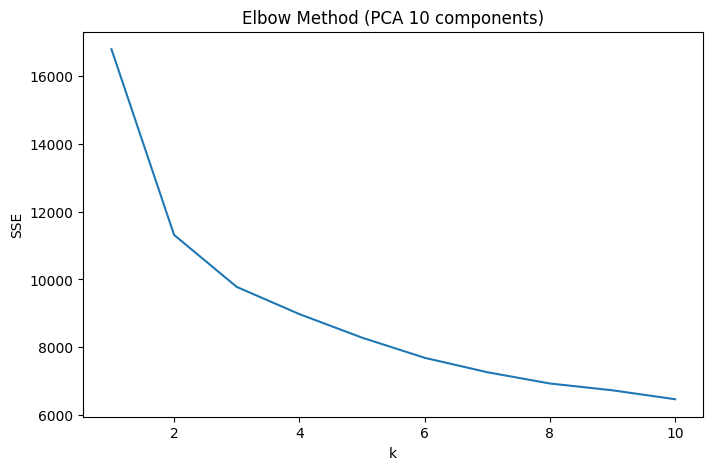

Randomly selected indices for centroids: [547 392]
Randomly selected indices for centroids: [390  96]
Randomly selected indices for centroids: [138 377]
Randomly selected indices for centroids: [ 47 158]
Randomly selected indices for centroids: [150 246]
Randomly selected indices for centroids: [562 329]
Randomly selected indices for centroids: [ 35 524]
Randomly selected indices for centroids: [ 51 519]
Randomly selected indices for centroids: [482 304]
Randomly selected indices for centroids: [319 458]
Best SSE with PCA-reduced data: 11311.926102143156
Cluster assignments for each data point: [0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 1 1 1 1 0 1 1 0 1 0 1 1 1 1 1 0 1 1 0 0 1 1 1 1 0 1 0 0 1 1 0 1 0 1 0 1
 1 0 1 0 0 1 1 0 0 0 1 0 1 0 1 0 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 0 1 1 0 1 1
 1 0 1 1 1 1 0 0 1 1 0 0 1 1 1 1 0 0 0 1 0 0 1 0 1 1 1 0 1 1 0 1 1 1 1 0 1
 1 1 1 1 0 1 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 1 1 1 0 1 1 1 1 0 1 1 0 0 1 1 1
 1 1 1 1 1 0 1 1 0 0 1 

In [ ]:
# Reduce with PCA
X_reduced, _, _ = PCA(X_scaled, n_components=10)

# Elbow method on the reduced data
sse_list = []
k_range  = range(1, 11)

for k in (k_range):
    best_sse = float('inf')
    for _ in range(10):                              # 10 random restart
        labels, centroids, sse = kmeans(X_reduced, k=k)   # uses PCA output
        if sse < best_sse:
            best_sse = sse
    sse_list.append(best_sse)

# Plot elbow
plt.figure(figsize=(8, 5))
plt.plot(list(k_range), sse_list)
plt.xlabel('k'); plt.ylabel('SSE')
plt.title('Elbow Method (PCA 10 components)')
plt.show()

#Final clustering with best k
best_k = 3  # from elbow plot
best_sse, best_labels = float('inf'), None

for _ in range(10):
    labels, centroids, sse = kmeans(X_reduced, k=best_k)  # uses PCA output
    if sse < best_sse:
        best_sse, best_labels = sse, labels
print("Best SSE with PCA-reduced data:", best_sse)
print("Cluster assignments for each data point:", best_labels)